In [1]:
!pip install transformers timm datasets torch torchvision
!pip install huggingface_hub

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing

2025-09-07 07:23:54.747382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757229834.949951      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757229835.005199      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

DATA_PATH = "/kaggle/input/751510/75-15-10"

# Augmentasi untuk train
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformasi untuk validasi & test
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=train_transform)


total_size = len(full_dataset) 
train_size = int(0.75 * total_size)   
val_size = int(0.15 * total_size)    
test_size = total_size - train_size - val_size 


train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) 
)

# Ganti transform untuk val & test
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Info dataset
num_classes = len(full_dataset.classes)
print(f"Jumlah Kelas: {num_classes}, Label: {full_dataset.classes}")
print(f"Total gambar: {total_size} (Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)})")


Jumlah Kelas: 6, Label: ['bulging', 'cataract', 'crossed', 'hordeolum', 'normal', 'uveitis']
Total gambar: 1962 (Train=1471, Val=294, Test=197)


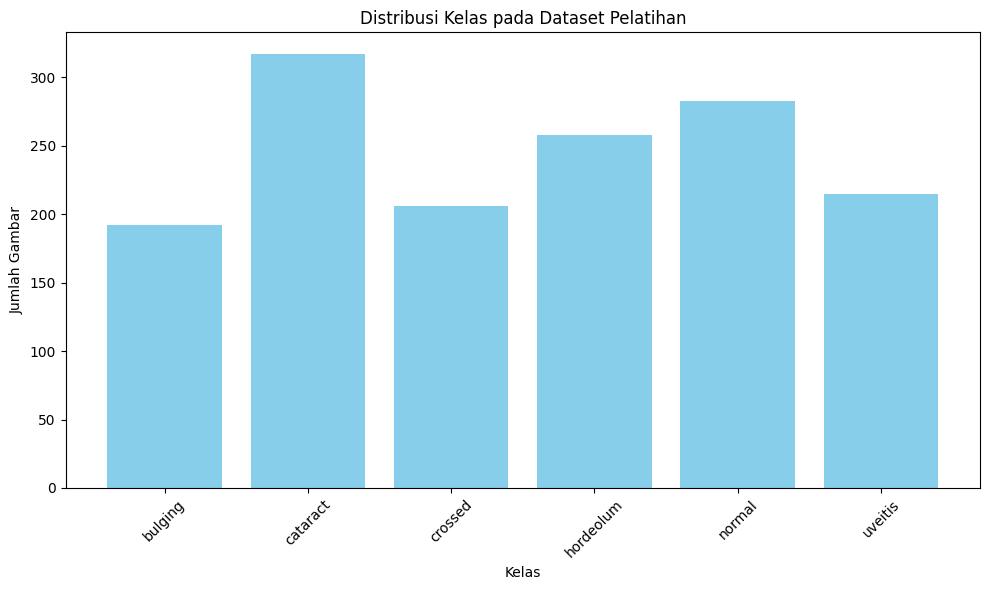

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Ambil label langsung dari train_dataset
train_labels = [label for _, label in train_dataset]

# Hitung jumlah masing-masing kelas
class_counts = Counter(train_labels)
class_names = train_dataset.dataset.classes  # ambil dari dataset asli
counts = [class_counts[i] for i in range(len(class_names))]

# Plot distribusi kelas
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts, color='skyblue')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Kelas pada Dataset Pelatihan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


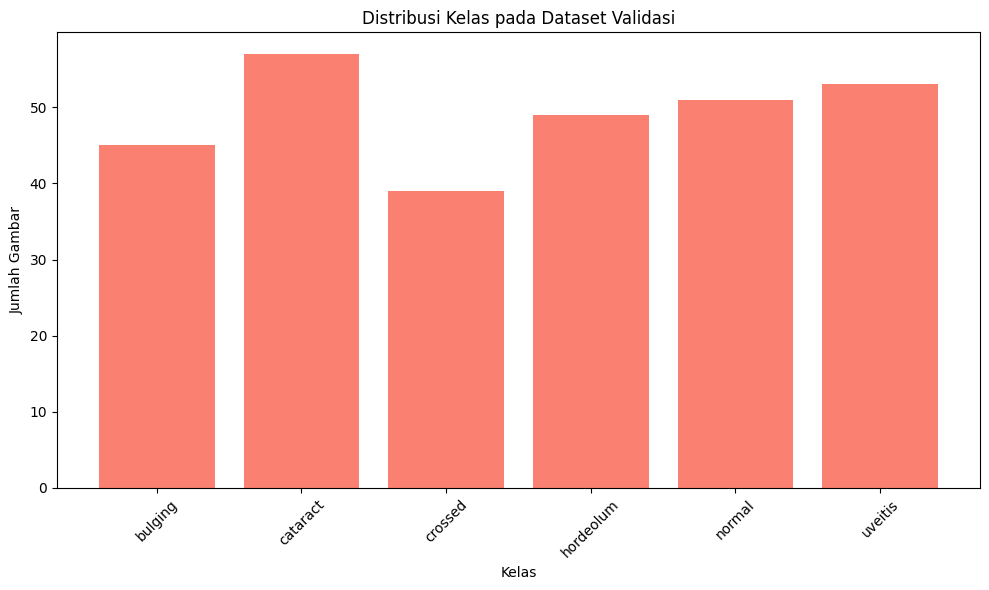

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

# Ambil label dari dataset validasi
val_labels = [label for _, label in val_dataset]

# Hitung jumlah masing-masing kelas
val_class_counts = Counter(val_labels)
val_class_names = val_dataset.dataset.classes  # ambil dari dataset asli
val_counts = [val_class_counts[i] for i in range(len(val_class_names))]

# Plot distribusi kelas validasi
plt.figure(figsize=(10, 6))
plt.bar(val_class_names, val_counts, color='salmon')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Kelas pada Dataset Validasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


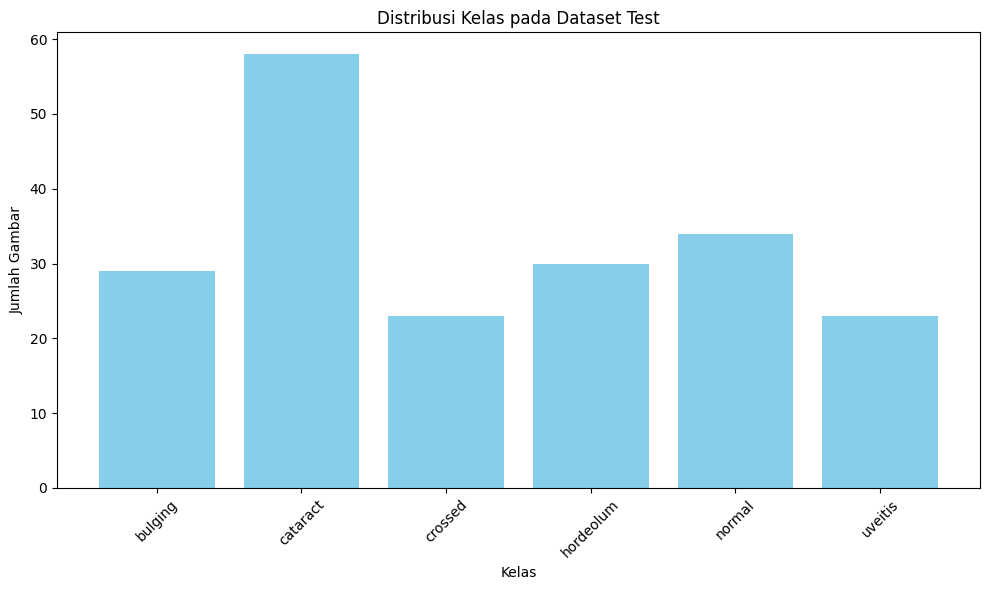

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Ambil label dari dataset test
test_labels = [label for _, label in test_dataset]

# Hitung jumlah masing-masing kelas
test_class_counts = Counter(test_labels)
test_class_names = test_dataset.dataset.classes  # ambil dari dataset utama
test_counts = [test_class_counts[i] for i in range(len(test_class_names))]

# Plot distribusi kelas test
plt.figure(figsize=(10, 6))
plt.bar(test_class_names, test_counts, color='skyblue')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Kelas pada Dataset Test")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
import timm
from tqdm import tqdm

model = timm.create_model("convnextv2_base.fcmae_ft_in1k", pretrained=True, num_classes=num_classes)
model = model.to(device)

# Hyperparameter
epochs = 50
learning_rate = 1e-4

# Optimizer & Loss Function
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / total_train
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / total_val
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_accuracy:.2f}% | Train Loss: {avg_train_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}% | Val Loss: {avg_val_loss:.4f}")


model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

100%|██████████| 46/46 [01:23<00:00,  1.80s/it]


Epoch 1/50 | Train Acc: 73.42% | Train Loss: 0.8433 | Val Acc: 88.78% | Val Loss: 0.3867


100%|██████████| 46/46 [01:22<00:00,  1.79s/it]


Epoch 2/50 | Train Acc: 95.79% | Train Loss: 0.1900 | Val Acc: 93.20% | Val Loss: 0.3040


...

Epoch 48/50 | Train Acc: 100.00% | Train Loss: 0.0005 | Val Acc: 97.96% | Val Loss: 0.0828


100%|██████████| 46/46 [01:22<00:00,  1.79s/it]


Epoch 49/50 | Train Acc: 100.00% | Train Loss: 0.0005 | Val Acc: 97.96% | Val Loss: 0.0832


100%|██████████| 46/46 [01:22<00:00,  1.78s/it]


Epoch 50/50 | Train Acc: 100.00% | Train Loss: 0.0004 | Val Acc: 97.96% | Val Loss: 0.0834


In [7]:
# Evaluasi di Test Set setelah training selesai
model.eval()
test_loss = 0.0
test_correct = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / total_test
avg_test_loss = test_loss / len(test_loader)

print(f"\nFinal Test Accuracy: {test_accuracy:.2f}% | Test Loss: {avg_test_loss:.4f}")



Final Test Accuracy: 98.98% | Test Loss: 0.0460


Final Train Accuracy: 100.00%
Final Validation Accuracy: 97.96%


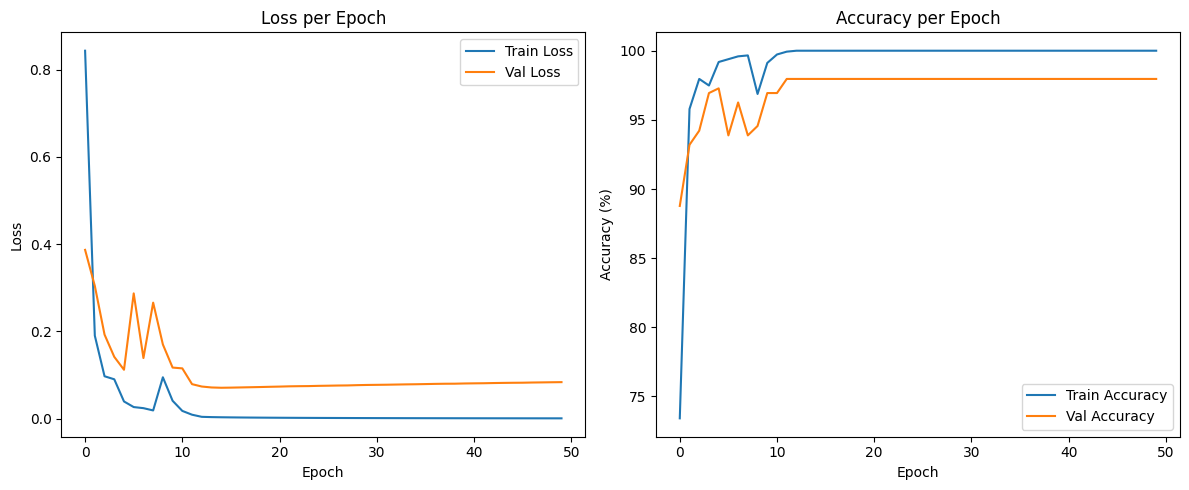

In [8]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, 
    recall_score, f1_score, roc_auc_score, roc_curve
)
import seaborn as sns

# Final Accuracy
print(f"Final Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

# Visualisasi Loss & Akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Konversi ke numpy
y_true = np.array(all_labels)
y_pred = np.array(all_preds)


print(f"Akurasi  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Metrik per kelas
print("\n=== METRIK EVALUASI PER KELAS ===")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))


Akurasi  : 0.9796
Precision: 0.9803
Recall   : 0.9796
F1 Score : 0.9796

=== METRIK EVALUASI PER KELAS ===
              precision    recall  f1-score   support

     bulging       1.00      1.00      1.00        45
    cataract       1.00      0.96      0.98        57
     crossed       1.00      0.97      0.99        39
   hordeolum       0.98      0.94      0.96        49
      normal       0.96      1.00      0.98        51
     uveitis       0.95      1.00      0.97        53

    accuracy                           0.98       294
   macro avg       0.98      0.98      0.98       294
weighted avg       0.98      0.98      0.98       294



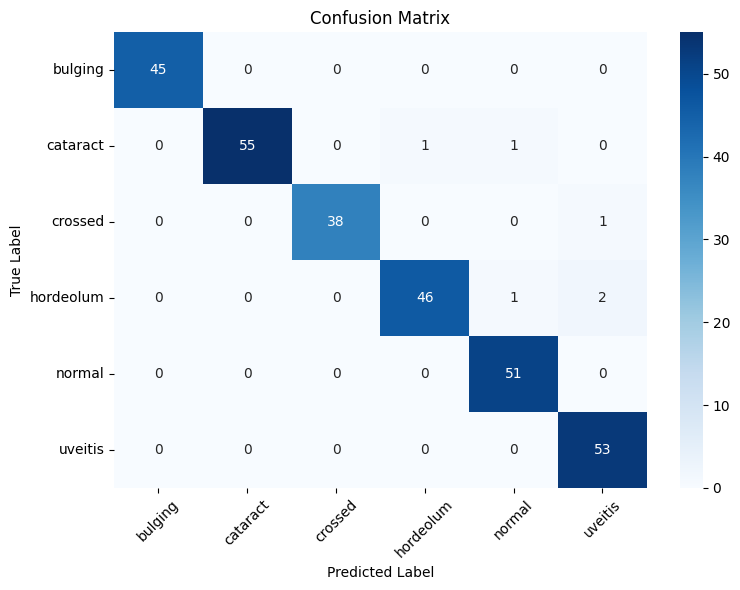

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


class_names = ['bulging', 'cataract', 'crossed', 'hordeolum', 'normal', 'uveitis']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


if len(np.unique(y_true)) == 2:
    y_prob_class1 = y_prob[:, 1]  
    fpr, tpr, _ = roc_curve(y_true, y_prob_class1)
    auc = roc_auc_score(y_true, y_prob_class1)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


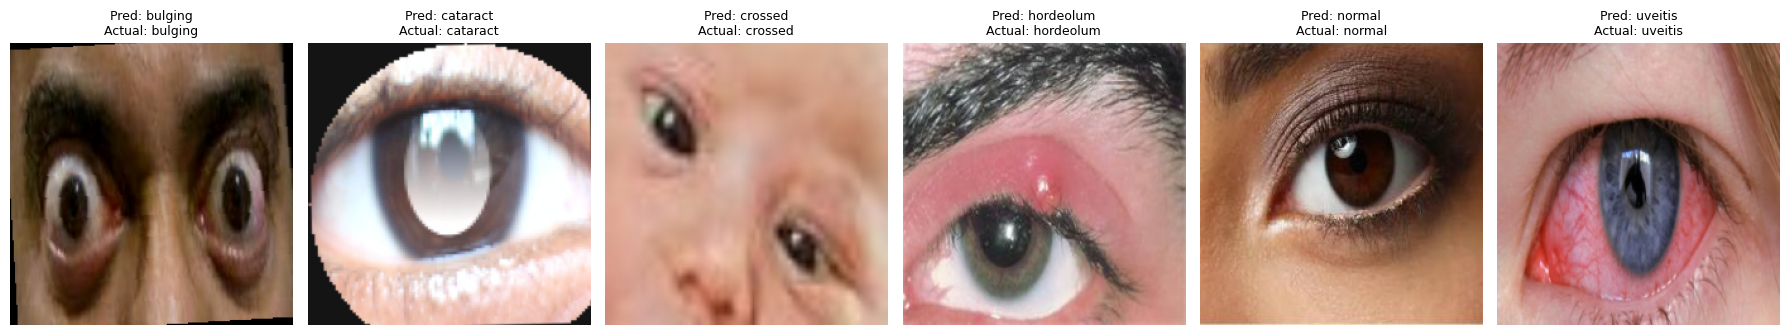

In [ ]:
import random
import matplotlib.pyplot as plt

# Cari indeks per kelas di test_dataset
class_indices = {cls: [] for cls in range(len(test_dataset.dataset.classes))}
for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    class_indices[label].append(idx)

# Ambil 1 random sample dari tiap kelas
selected_samples = []
for cls, indices in class_indices.items():
    if indices:  # pastikan kelas ada
        chosen_idx = random.choice(indices)
        selected_samples.append((test_dataset[chosen_idx], cls))

# Fungsi prediksi
def predict_tensor(image_tensor):
    image_tensor = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        predicted_class_idx = torch.argmax(output, dim=1).item()
    return test_dataset.dataset.classes[predicted_class_idx]

# Plot
fig, axes = plt.subplots(1, len(selected_samples), figsize=(18, 4))
if len(selected_samples) == 1:  # kalau cuma satu kelas
    axes = [axes]

for i, ((img_tensor, actual_label), cls) in enumerate(selected_samples):
    predicted_label = predict_tensor(img_tensor)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()

    # Undo normalisasi
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img = (img * std + mean).clip(0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Pred: {predicted_label}\nActual: {test_dataset.dataset.classes[actual_label]}", fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
torch.save(model.state_dict(), "convnextv2_94%.pth")